<a href="https://colab.research.google.com/github/jumafernandez/generacion_prompts/blob/main/semana6/knowledge_graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import openai
import os
import matplotlib as plt

In [ ]:
os.environ["OPENAI_API_KEY"] = ""

In [ ]:
# Create an OpenAI client instance
client = openai.OpenAI()

In [ ]:
datos_="""Nombre_Cliente,Prenda,Precio,Descuento,Metodo_Pago,Precio_Final
Carmen,Jeans,25.83,19,Efectivo,20.92
Javier,Falda,94.43,29,Tarjeta Crédito,67.05
María,Blusa,94.71,14,Tarjeta Débito,81.45
Carlos,Vestido,47.31,17,Efectivo,39.27
María,Corbata,93.92,17,Efectivo,77.95
Javier,Falda,17.59,18,Transferencia,14.42
María,Jeans,32.22,29,Transferencia,22.88
Lucía,Falda,77.86,2,Efectivo,76.3
Fernando,Jeans,48.73,19,Tarjeta Crédito,39.47
María,Blusa,66.42,3,Tarjeta Débito,64.43
Alejandro,Zapatos,99.14,5,Transferencia,94.18
Teresa,Corbata,99.01,22,Efectivo,77.23
María,Vestido,64.71,11,Efectivo,57.59
Ana,Jeans,27.61,2,PayPal,27.06
"""

In [ ]:
datos_

'Nombre_Cliente,Prenda,Precio,Descuento,Metodo_Pago,Precio_Final\nCarmen,Jeans,25.83,19,Efectivo,20.92\nJavier,Falda,94.43,29,Tarjeta Crédito,67.05\nMaría,Blusa,94.71,14,Tarjeta Débito,81.45\nCarlos,Vestido,47.31,17,Efectivo,39.27\nMaría,Corbata,93.92,17,Efectivo,77.95\nJavier,Falda,17.59,18,Transferencia,14.42\nMaría,Jeans,32.22,29,Transferencia,22.88\nLucía,Falda,77.86,2,Efectivo,76.3\nFernando,Jeans,48.73,19,Tarjeta Crédito,39.47\nMaría,Blusa,66.42,3,Tarjeta Débito,64.43\nAlejandro,Zapatos,99.14,5,Transferencia,94.18\nTeresa,Corbata,99.01,22,Efectivo,77.23\nMaría,Vestido,64.71,11,Efectivo,57.59\nAna,Jeans,27.61,2,PayPal,27.06\n'

In [ ]:
pregunta = """Quiero que tomando en cuenta los datos del contexto extraigas entidades y relaciones entre los datos con el objetivo de crear un grafico de conocimiento tipo knowledge graph, el formato de salida debe ser para la libreria networkx de python. Este es un ejemplo de salida, puede haber mas relaciones y mas nodos, solo tomalo como ejemplo:
[('Carmen', 'Jeans', {'Precio': 25.83, 'Descuento': 19, 'Metodo_Pago': 'Efectivo', 'Precio_Final': 20.92}),
('Javier', 'Falda', {'Precio': 94.43, 'Descuento': 29, 'Metodo_Pago': 'Tarjeta Crédito', 'Precio_Final': 67.05})]
"""

# Combinamos el contexto de la conversación y la pregunta adicional en un prompt
prompt = f"{datos_}\n\nP: {pregunta}\nR:"

response = client.chat.completions.create(
    model='gpt-4',
    max_tokens=1500,
    messages=[
        {"role": "system", "content": "Eres un asistente util, tu objetivo principal es extraer relaciones entre entidades y datos"},
        {"role": "user", "content": prompt},
    ])

message = response.choices[0].message
print("{}: {}".format(message.role, message.content))

assistant: [('Carmen', 'Jeans', {'Precio': 25.83, 'Descuento': 19, 'Metodo_Pago': 'Efectivo', 'Precio_Final': 20.92}),
('Javier', 'Falda', {'Precio': 94.43, 'Descuento': 29, 'Metodo_Pago': 'Tarjeta Crédito', 'Precio_Final': 67.05}),
('María', 'Blusa', {'Precio': 94.71, 'Descuento': 14, 'Metodo_Pago': 'Tarjeta Débito', 'Precio_Final': 81.45}),
('Carlos', 'Vestido', {'Precio': 47.31, 'Descuento': 17, 'Metodo_Pago': 'Efectivo', 'Precio_Final': 39.27}),
('María', 'Corbata', {'Precio': 93.92, 'Descuento': 17, 'Metodo_Pago': 'Efectivo', 'Precio_Final': 77.95}),
('Javier', 'Falda', {'Precio': 17.59, 'Descuento': 18, 'Metodo_Pago': 'Transferencia', 'Precio_Final': 14.42}),
('María', 'Jeans', {'Precio': 32.22, 'Descuento': 29, 'Metodo_Pago': 'Transferencia', 'Precio_Final': 22.88}),
('Lucía', 'Falda', {'Precio': 77.86, 'Descuento': 2, 'Metodo_Pago': 'Efectivo', 'Precio_Final': 76.3}),
('Fernando', 'Jeans', {'Precio': 48.73, 'Descuento': 19, 'Metodo_Pago': 'Tarjeta Crédito', 'Precio_Final': 39.4

In [ ]:
import networkx as nx

G = nx.MultiDiGraph()

data = eval(message.content)

for d in data:
    G.add_edge(d[0], d[1], **d[2])

{('Carmen',
  'Jeans'): Text(0.1730034684132049, -0.28758265272033345, '$20.92 - 19%'),
 ('Javier',
  'Falda'): Text(0.18197873243079288, 0.9109304719098137, '$14.42 - 18%'),
 ('María',
  'Blusa'): Text(-0.08417300597406163, -0.6683423301045961, '$64.43 - 3%'),
 ('María',
  'Corbata'): Text(-0.3052092407193235, -0.6154402542212618, '$77.95 - 17%'),
 ('María',
  'Jeans'): Text(0.2886028297955745, -0.3827140679449491, '$22.88 - 29%'),
 ('María',
  'Vestido'): Text(0.021547859545454684, 0.32196710576960097, '$57.59 - 11%'),
 ('Carlos',
  'Vestido'): Text(0.21589245085602304, 0.693956895813761, '$39.27 - 17%'),
 ('Lucía',
  'Falda'): Text(0.10856236280986731, 0.7963049866191592, '$76.3 - 2%'),
 ('Fernando',
  'Jeans'): Text(0.09324931642475931, -0.496962264412233, '$39.47 - 19%'),
 ('Alejandro',
  'Zapatos'): Text(0.2181088746382437, 0.13325266179334294, '$94.18 - 5%'),
 ('Teresa',
  'Corbata'): Text(-0.26624733900917785, -0.9034258907358138, '$77.23 - 22%'),
 ('Ana',
  'Jeans'): Text(0.17

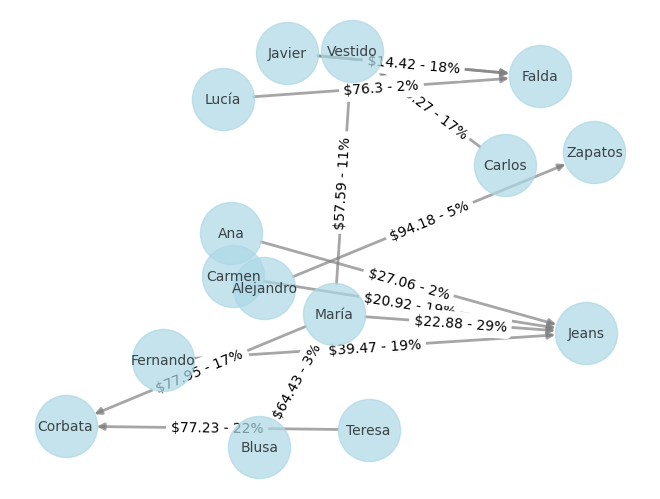

In [ ]:
pos = nx.spring_layout(G, k=0.9)  # Usar el layout spring para la posición de los nodos
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_size=10, edge_color='gray', width=2, alpha=0.7)

# Etiquetas de los bordes
edge_labels = {(n1, n2): '$'+str(data['Precio_Final'])+' - '+str(data['Descuento'])+'%' for n1, n2, data in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

